(statistical-mechanics:ising:numerics)=
# Ising model - Numerics


Some references:
- https://farside.ph.utexas.edu/teaching/329/lectures/node110.html
- O.Rojas, Spectral mechanism and nearly reducible transfer matrices for pseudotransitions in one-dimensional systems, https://arxiv.org/html/2511.18109v2
- L.Onsager, 1944, https://arxiv.org/html/2412.07328v1 *really useful?*

In [1]:
"""
Ising model on regular 2D lattice with periodic boundaries

The Hamiltonian, H, is used to define the probability of the (micro)states of the system
following a Boltzmann probability distribution p_i ~ e^( - E_i / T ) = e^( - beta * E_i ).
The expression of the Hamiltonian reads: H = .5 * J_{ij} s_i s_j + M p_i s_i

First with low-dimensional lattice:
Then increasing the dimensions:

Samples states from the distribution p_i using Metropolis-Hastings method

"""

import numpy as np


## $m \times n$ lattice

In [2]:
#> Useful functions for ising model on 2D lattice
class IsingLattice():
    def __init__(self, m=3, n=3, J=1., M=0., T=1.):
        """  """
        self.m = m
        self.n = n
        self.J = J
        self.M = M
        self.T = T

    def initialize(self,):
        """  """
        set_random_state()
        # Other initializations? Compatible with {-1, +1} spin values

    def set_random_state(self,):
        """  """
        self.state = 2 * np.random.randint(0,2, size=(self.m, self.n)) - 1
        self.E0 = self.compute_total_energy()

    def flip_indices(self,):
        """  """
        return np.random.randint(0, self.m), np.random.randint(0, self.n)

    def flip_loc(self, i,j):
        """  """
        self.state[i,j] *= -1
        
    def flip(self,):
        """  """
        self.state[self.flip_indices()] *= -1

    def compute_local_energy(self, i,j):
        """
        Energy contribution due to [i,j] element of state reads
          E_local[i,j] = - J s[i,j] \sum_{(k,l)\in B(i,j)} s[k,l] - M s[i,j]
        Flipping the state, s[i,j] -> -s[i,j], gives a energy difference
        E_local_flip[i,j] - E_local[i,j] = 2 ( J s[i,j] \sum_{} s[k,l] + M s[i,j] ) =
                                        = - 2 E_local[i,j]
        """
        neighbor_sum = self.state[(i+1)%self.m, j] + self.state[(i-1)%self.m, j] + \
                       self.state[i, (j+1)%self.n] + self.state[i, (j-1)%self.n]
        return - self.state[i,j] * ( self.J * neighbor_sum + self.M )
    
    def compute_total_energy(self,):
        # For efficiency, use vector operations and avoid nested for loops
        # Just shift up and left, to avoid double counting in an efficient way
        up = np.roll(self.state, shift=1, axis=0)
        left = np.roll(self.state, shift=1, axis=1)
        
        # Energy = -J * sum(spin * neighbors)
        return - self.J * np.sum(self.state * (up + left)) - self.M * np.sum(self.state)

    def compute_total_magnetization(self,):
        """  """
        return np.sum(isi.state)
    
    def compute_avg_magnetization(self,):
        """  """
        return np.mean(isi.state)

    def metropolis_hastings_run(self, n_steps=100, output_states=False):
        """   """
        E = self.compute_total_energy()
        Es = [ E ]
        Ms = [ self.compute_total_magnetization() ]
        states = []
        
        if output_states: states += [ self.state.copy() ]
            
        i_step = 0
        for i_step in range(n_steps):
            #> 1 step of Metropolis-Hastings algorithm
            dE = self.metropolis_hastings_step()   # Updating state with flip
            E += dE                                # Update system energy

            #> Update output arrays
            Es += [ E ]
            Ms += [ self.compute_total_magnetization() ]
            if output_states:
                states += [ self.state.copy() ]   # <-- ! Memory. Add some sampling period, 
                                                  # or dumping method. Don't store the state
                                                  # at all the timesteps.
            #> Update step index
            i_step += 1

        return Es, Ms, states
    
    def metropolis_hastings_step(self,):
        """  """
        #> Proposal step
        i_flip, j_flip = self.flip_indices()                 # random sampling of the flip indices
        dE = - 2 * self.compute_local_energy(i_flip, j_flip) # evaluate delta energy

        if dE < 0:   # accept
            self.flip_loc(i_flip, j_flip)
        else:
            p_flip = np.exp( -dE / self.T )
            
            if np.random.random() < p_flip:       # flip
                self.flip_loc(i_flip, j_flip)
            else:                                 # reject flip proposal
                dE = 0

        return dE



In [3]:
#> Parameters
m, n = 32,32   # 16, 16
J, M = 1., 0.  # 1.
Tc = 2.26918   # 2.26918 * J/k = T_critical
T = Tc * 1.

#> Ising Lattice Model
isi = IsingLattice(m=m, n=n, T=T, M=M, J=J)
isi.set_random_state()

print(f"Lattice dimensions: {m},{n}")
print( "Initial conditions:")
print(f"Energy       : {isi.E0}")
print(f"N. of spin up: {np.sum(isi.state[isi.state > 0])}")
print(f"Magnetization: {np.sum(isi.state)}")

#> Run Metropolis-Hastings algorithm
Es, Ms, states = isi.metropolis_hastings_run(n_steps=int(1e6), output_states=True)


Lattice dimensions: 32,32
Initial conditions:
Energy       : -16.0
N. of spin up: 520
Magnetization: 16


KeyboardInterrupt: 

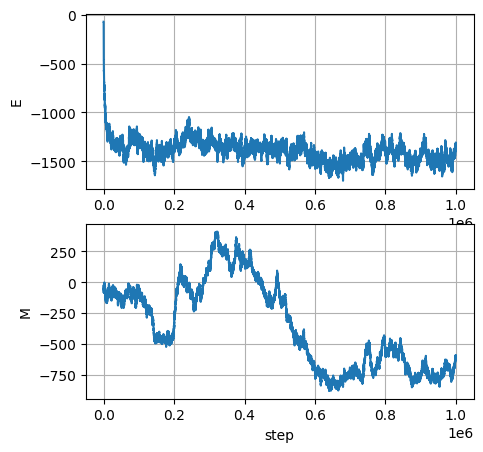

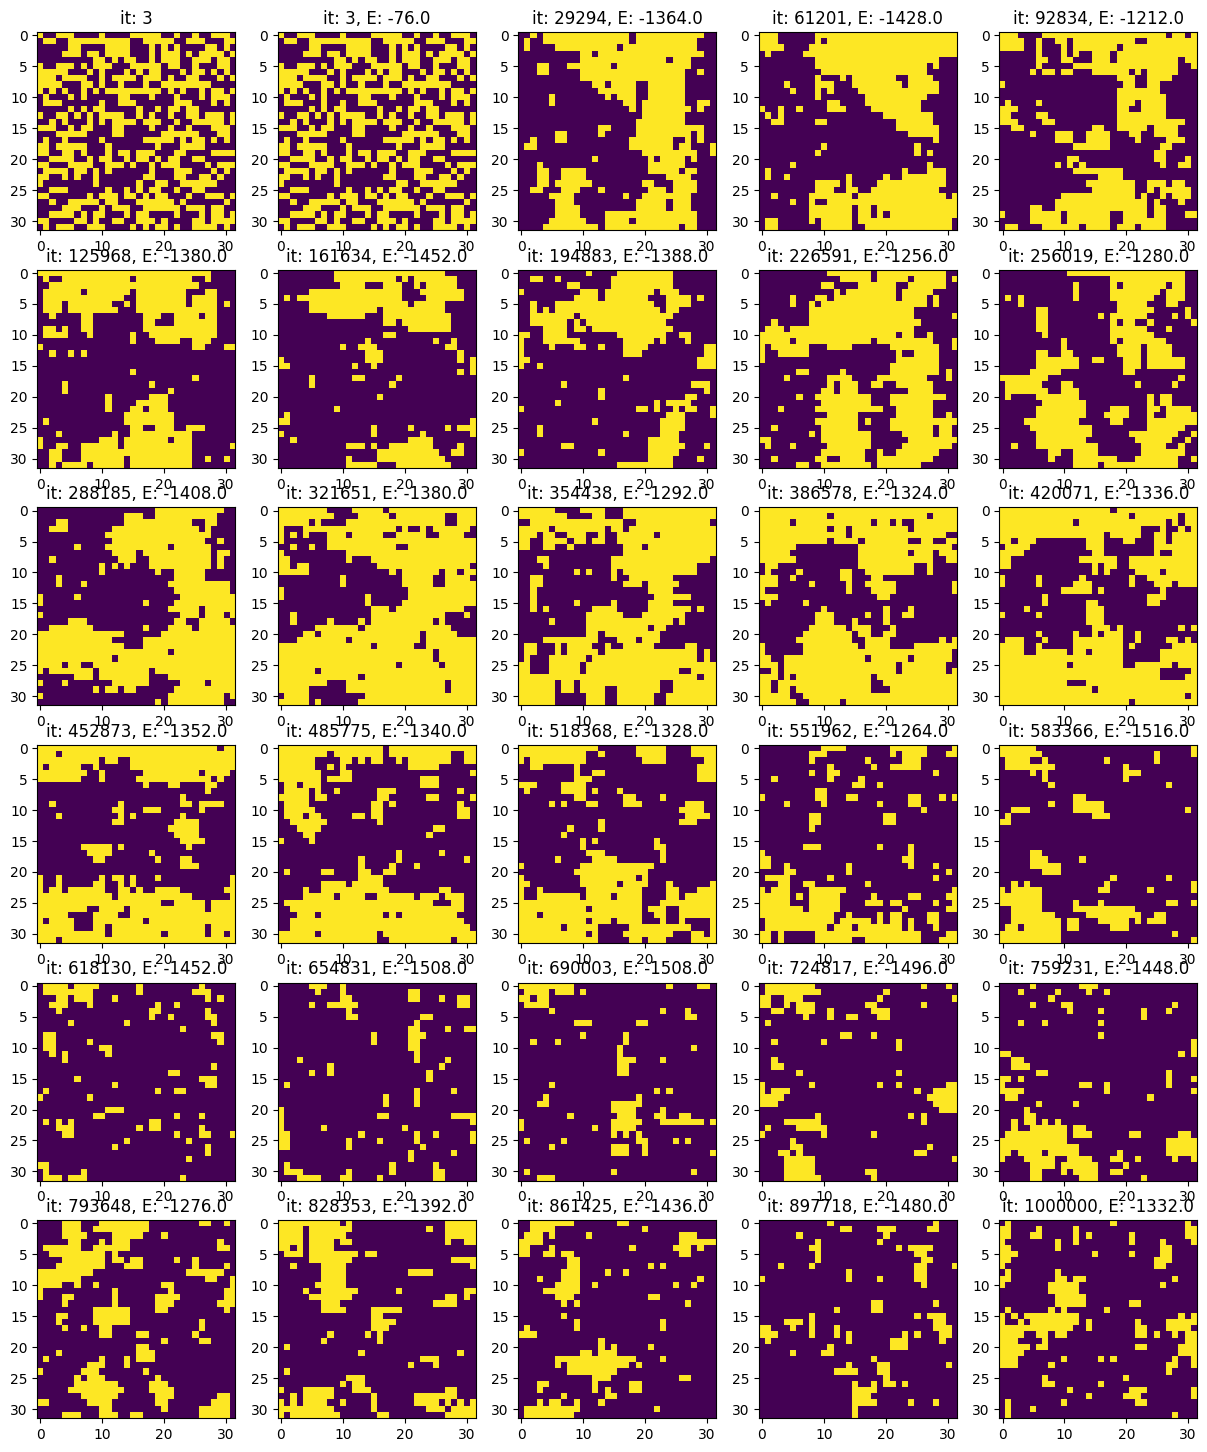

In [185]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1, figsize=(5,5))
ax[0].plot(Es);  ax[0].set_ylabel('E');  ax[0].grid()
ax[1].plot(Ms);  ax[1].set_ylabel('M');  ax[1].grid()
ax[1].set_xlabel('step')

nrows_plots = 6
ncols_plots = 5
n_plots = nrows_plots * ncols_plots
i_plot = 0

#> Indices of all the flipping time steps
indices = np.where(np.diff(Es) != 0)[0] + 1
n_flips = len(indices)

d_indices = np.max([n_flips // n_plots, 1])
indices_plot = indices[d_indices * np.arange(n_plots)]
indices_plot[n_plots - 2] = len(Es)-1

# print(d_indices)
# print(np.arange(n_plots))
# print(indicesthere
# print(indices_plot)

fig, ax = plt.subplots(nrows_plots, ncols_plots, figsize=(3*ncols_plots, 3*nrows_plots))

ax[0,0].imshow(states[0])
ax[0,0].set_title(f"it: {indices_plot[i_plot]}")
i_plot += 1

while i_plot < n_plots and i_plot < len(indices):

    row_plot = i_plot // ncols_plots
    col_plot = i_plot - row_plot * ncols_plots
    
    ax[row_plot, col_plot].imshow(states[indices_plot[i_plot-1]], vmin=-1, vmax=1)
    ax[row_plot, col_plot].set_title(f"it: {indices_plot[i_plot-1]}, E: {Es[indices_plot[i_plot-1]]}")
    
    i_plot += 1
    
plt.show()

In [180]:
from scipy.special import logsumexp

#> Sample the stationary probability density function
burn_in = 5000                           # From visual inspection
Es_stationary = np.array(Es[burn_in:])   # Discard transient evolution

#> Evaluate P(E) from time history
energy_levels, counts = np.unique(Es_stationary, return_counts=True)
pE = counts / np.sum(counts)

ln_g_tilde = np.log(pE) + energy_levels / isi.T

# N = 2 ** (isi.m, isi.n)
ln_N = isi.m * isi.m * np.log(2)

ln_Z = ln_N - logsumexp(ln_g_tilde)
ln_g = ln_Z + ln_g_tilde

#> P(M) probability distribution of magnetization, from time history
Ms_stationary = np.array(Ms[burn_in:])   # Discard transient evolution
mag_levels, mag_counts = np.unique(Ms_stationary, return_counts=True)
pM = mag_counts / np.sum(mag_counts)



Text(0, 0.5, 'P(M)')

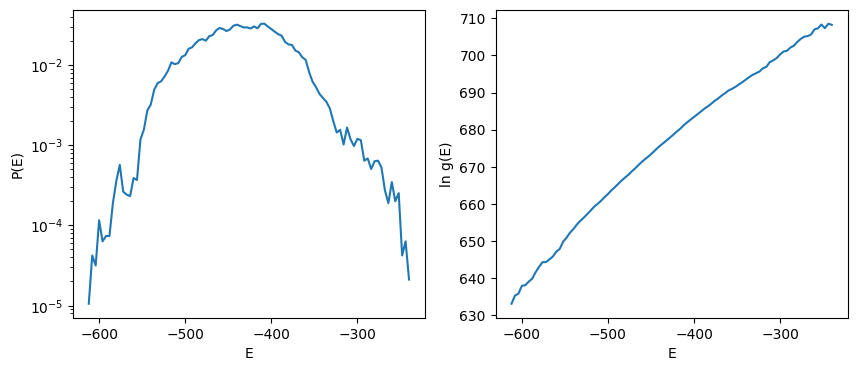

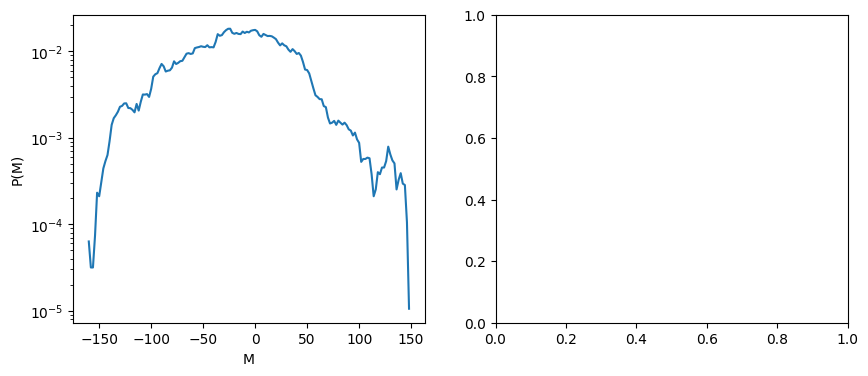

In [186]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].semilogy(energy_levels, pE)
ax[1].plot(energy_levels, ln_g)

ax[0].set_xlabel('E');  ax[0].set_ylabel('P(E)')
ax[1].set_xlabel('E');  ax[1].set_ylabel('ln g(E)')

# ---
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].semilogy(mag_levels, pM)
# ax[1].plot(energy_levels, ln_g)

ax[0].set_xlabel('M');  ax[0].set_ylabel('P(M)')
# ax[1].set_xlabel('E');  ax[1].set_ylabel('ln g(E)')


In [135]:
"""
Old script using histrograms

#> Sample the stationary probability density function
burn_in = 1000                           # From visual inspection
Es_stationary = np.array(Es[burn_in:])   # Discard transient evolution

fig, ax = plt.subplots(1,1, figsize=(5,5))
ax.hist(Es_stationary, density=True)
ax.grid()
ax.set_xlabel('E')
# ax.plot(Es_stationary, np.exp(Es_stationary/isi.T), color='red')

# P(E) = g(E) * exp(-beta*E) / Z
# Z is the partition function, that works as the normalization factor
# g(E) is the number of degenerate states with energy = E
# Thus:
# - P(E) can be evaluated from samples
# - exp(-beta*E) is known for every value E
# - g(E) / Z can be evaluated as P(E) / exp(-beta*E) for every value E
#
# Z = sum_E ( g(E) * exp(-beta*E) )
# ...is it possible to find Z and thus g(E)?

"""


"\nOld script using histrograms\n\n#> Sample the stationary probability density function\nburn_in = 1000                           # From visual inspection\nEs_stationary = np.array(Es[burn_in:])   # Discard transient evolution\n\nfig, ax = plt.subplots(1,1, figsize=(5,5))\nax.hist(Es_stationary, density=True)\nax.grid()\nax.set_xlabel('E')\n# ax.plot(Es_stationary, np.exp(Es_stationary/isi.T), color='red')\n\n# P(E) = g(E) * exp(-beta*E) / Z\n# Z is the partition function, that works as the normalization factor\n# g(E) is the number of degenerate states with energy = E\n# Thus:\n# - P(E) can be evaluated from samples\n# - exp(-beta*E) is known for every value E\n# - g(E) / Z can be evaluated as P(E) / exp(-beta*E) for every value E\n#\n# Z = sum_E ( g(E) * exp(-beta*E) )\n# ...is it possible to find Z and thus g(E)?\n\n"

The relation between state probability $P(E)$ - i.e. probability of getting a microstate with energy $E$ -, degeneracy number $g(E)$ - i.e. the number of microstates with energy $E$ - and the Boltzmann distribution $\propto e^{-\beta E}$ reads

$$P(E) = \frac{g(E) e^{-\beta E}}{Z} = \frac{g(E) e^{-\beta E}}{\sum_{E'} g(E') e^{-\beta E'}} \ .$$

Once the value $E$ of energy levels is known, the exponential is known. Probability $P(E)$ is sampled from experiments. Thus

$$\frac{g(E)}{Z} = P(E) e^{\beta E} \ .$$

If the total number of microstate is not known, $g(E)$ can be evaluated up to a multiplicative constant.


If the total number of microstates is known, $\sum_E g(E) = N$, it's possible to compute all the values of $g(E)$ and $Z$. In this case, a linear system reads

$$\begin{cases} 
  g(E) = Z P(E) e^{\beta E} \\ \\
  \displaystyle\sum_{E'} g(E') = N \ ,
\end{cases}$$

and thus

$$\begin{aligned}
  Z = \frac{N}{\sum_{E'} P(E') e^{\beta E'}} \quad , \quad
  g(E) = \frac{N P(E) e^{\beta E}}{\sum_{E'} P(E') e^{\beta E'}} \ .
\end{aligned}$$

**Log to avoid numerical exceptions.**

$$\ln g(E) = \ln Z + \ln P(E) + \beta E$$

In order to evaluate $Z$,

$$Z = \sum_{E} g(E) e^{-\beta E} = \sum_{E} e^{\ln g(E) - \beta E} \ ,$$

and avoid overflow, the largest contribution is factored using the relation

$$\ln \sum_i e^{x_i} = \ln \left( e^{x_{max}} \sum_i  e^{-(x_{max}-x_i)} \right) = \ln e^{x_{max}} + \ln \sum_i e^{-(x_{max} - x_i )} = x_{max} +  \ln \sum_i e^{-(x_{max} - x_i )} \ .$$


The largest exponential corresponds to energy value $E_0$ at the maximum of $P(E)$ as

$$\begin{aligned}
  E_0
  & = \text{argmax}_{E} \left( \ln g(E) - \beta E \right) =  \\
  & = \text{argmax}_{E} \left( \ln Z + \ln P(E) \right) =  \\
  & = \text{argmax}_{E} \ln P(E) = \\
  & = \text{argmax}_E P(E) \ .
\end{aligned}$$

Then the value of the partition function becomes

$$Z = \sum_E e^{\ln g(E) - \beta E} = \ln g(E_0) - \beta E_0 + \sum_E e^{- \Delta \left( \ln g(E) - \beta E \right)} \ ,$$

begin $\Delta f = f(E) - f(E_0)$, and $E_0$

If $N$ is known, $N = \sum_E g(E)$